**Subquestion 2:** which feature groups (reference network, low cost sensors, meteorology, atmospheric composition, temporal and spatial features) contribute most to inference accuracy?

This notebook retrains the XGBoost model under the same LOSO design while feature groups are removed.

| model | what is removed |
|---|---|
| full | nothing (reference model) |
| LCS | the 5 low cost sensor features |
| ERA5 | the 16 meteorology features |
| EAC4 | the 18 atmospheric composition features |
| ERA5+EAC4 | both reanalysis groups together |
| ERA5+EAC4+LCS | both reanalysis groups and the low cost sensors |
| neighbors | the 21 reference network features |
| GEO | latitude and longitude |
| Time | the 7 time encodings |
| GEO+Time | geo and time together |
| Engineered features | every constructed feature (the raw model, see below) |

That is 11 model variants, each trained per held out station. Every variant is scored by the change in RMSE and R2 relative to the full
model, with a paired Wilcoxon test on the per station RMSE and a BH correction over the 10 comparisons.

**The Engineered features** It removes every constructed feature and keeps only directly measured or reanalysis 
values: the neighbor readings nb_1 to nb_5, all meteorology variables, all EAC4 variables, lat/lon 
and the calendar encodings. The Veli corrected low cost sensor median (`lcs_median_pm25`) is added back as the only
semi raw LCS input. Removed as engineered: the 5 LCS correction and advection features, the 4 boundary layer derivations 
(low_blh, ventilation_coef, stagnant, stagnation_hours) and the constructed neighbor features (idw_neighbor,the nb1 lag block, 
the wind cones, the convection diffusion terms and the two missing indicators).

All neighbor derived features are rebuilt from the remaining 30 stations. The rebuild happens once per fold and is shared by all 11
variants of that fold. Results after the loop

## 1. Settings and paths

In [ ]:
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from scipy.stats import wilcoxon

# imputed station CSVs and the station coordinates location
DATA_DIR = r"C:\Users\Storm Anderson\Documents\UVA\Inferencing\XGboost\data_imputed"
COORDS_CSV = r"C:\Users\Storm Anderson\Documents\UVA\Inferencing\XGboost\station_cell_map.csv"

# outputs 
OUT_TABLES = os.path.join("results", "tables")
OUT_FIGURES = os.path.join("results", "figures")
os.makedirs(OUT_TABLES, exist_ok=True)
os.makedirs(OUT_FIGURES, exist_ok=True)

# time split
TRAIN_YEAR_MAX = 2022   
VAL_YEAR = 2023         
TEST_YEAR = 2024        

USE_GPU = True          # set to False on a pc without an NVIDIA GPU

# Optuna tuned hyperparameters
PARAMS = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "max_depth": 5,
    "learning_rate": 0.050174637405817,
    "min_child_weight": 11,
    "subsample": 0.5982185916706947,
    "colsample_bytree": 0.7254529566891234,
    "reg_lambda": 0.5349747167608838,
    "reg_alpha": 3.625170550327679,
    "gamma": 1.605431841969294,
    "tree_method": "hist",
    "seed": 42,
    "device": "cuda" if USE_GPU else "cpu",
}
N_ROUNDS = 2000     # maximum number of boosting rounds
EARLY_STOP = 50     # early stopping patience on the 2023 validation year

K_NEAREST = 5       # neighbors used for nb_1 to nb_5, idw_neighbor and the wind cones
K_QUAD = 8          # neighbors used for the quadratic surface fit
IDW_POWER = 2.0     # inverse distance weighting power
LAG_HOURS = [1, 3, 6, 24]

pd.set_option("display.max_columns", None)
print("device:", PARAMS["device"])

device: cuda


## 2. Feature groups (69 features in six groups)

In [ ]:
# the six feature groups, using the column names of the station CSVs
NETWORK_FEATURES = [
    "nb_1", "nb_2", "nb_3", "nb_4", "nb_5",
    "idw_neighbor",
    "nb1_lag_1h", "nb1_lag_3h", "nb1_lag_6h", "nb1_lag_24h",
    "nb1_24h_mean", "nb1_24h_std",
    "pm_upwind", "pm_downwind", "n_upwind", "n_downwind",
    "pm_gradient", "pm_advection", "pm_diffusion",
    "pm_upwind_isna", "pm_downwind_isna",
]

LCS_FEATURES = ["lcs_adv", "lcs_adv_coef", "f_rh", "lcs_x_frh", "lcs_rh_corrected"]

ERA5_FEATURES = [
    "t2m", "rh", "wind_speed", "wind_dir_sin", "wind_dir_cos",
    "sp", "ssr", "strd", "tp", "slhf", "sshf",
    "blh", "low_blh", "ventilation_coef", "stagnant", "stagnation_hours",
]

EAC4_FEATURES = [
    "aod550", "bcaod550", "duaod550", "ssaod550", "gtco3", "pm2p5",
    "co_1000hPa", "go3_1000hPa", "no2_1000hPa", "so2_1000hPa",
    "co_700hPa", "go3_700hPa", "no2_700hPa", "so2_700hPa",
    "co_500hPa", "go3_500hPa", "no2_500hPa", "so2_500hPa",
]

GEO_FEATURES = ["lat", "lon"]

TIME_FEATURES = ["hour_sin", "hour_cos", "doy_sin", "doy_cos", "dow_sin", "dow_cos", "year"]

ALL_FEATURES = (NETWORK_FEATURES + LCS_FEATURES + ERA5_FEATURES
                + EAC4_FEATURES + GEO_FEATURES + TIME_FEATURES)

print("features per group: network", len(NETWORK_FEATURES), "| lcs", len(LCS_FEATURES),
      "| era5", len(ERA5_FEATURES), "| eac4", len(EAC4_FEATURES),
      "| geo", len(GEO_FEATURES), "| time", len(TIME_FEATURES))
print("total features:", len(ALL_FEATURES))

# columns every fold table keeps next to the features
# lcs_median_pm25 is only used by the raw model in the ablation notebook
# the loop avoids duplicate columns, year is both an id column and a time feature
KEEP_COLS = ["station_id", "datetime", "year", "month", "ref_pm25", "lcs_median_pm25"]
for col in ALL_FEATURES:
    if col not in KEEP_COLS:
        KEEP_COLS.append(col)
print("columns per fold table:", len(KEEP_COLS))

features per group: network 21 | lcs 5 | era5 16 | eac4 18 | geo 2 | time 7
total features: 69
columns per fold table: 74


## 3. Load the data

In [ ]:
t0 = time.time()
station_folders = sorted(os.listdir(DATA_DIR))

stations = {}
for folder in station_folders:
    folder_path = os.path.join(DATA_DIR, folder)
    if not os.path.isdir(folder_path):
        continue  # skips loose files like imputation_report.csv
    df = pd.read_csv(os.path.join(folder_path, folder + ".csv"))
    df["datetime"] = pd.to_datetime(df["datetime"])
    df = df.sort_values("datetime").reset_index(drop=True)
    df["station_id"] = folder
    stations[folder] = df

STATION_IDS = list(stations.keys())

# station coordinates, also used as the geo features lat and lon
coords = pd.read_csv(COORDS_CSV)
coords = coords[coords["station_id"].isin(STATION_IDS)].set_index("station_id")[["lat", "lon"]]

for name in STATION_IDS:
    stations[name]["lat"] = coords.loc[name, "lat"]
    stations[name]["lon"] = coords.loc[name, "lon"]

# panel of the imputed reference PM2.5: rows are hours, columns are stations
# every neighbor feature below reads from this panel
panel = pd.DataFrame()
for name in STATION_IDS:
    df = stations[name]
    panel[name] = pd.Series(df["ref_pm25"].values, index=df["datetime"])
panel = panel.sort_index()

print("stations:", len(stations), "| panel shape:", panel.shape,
      "| loaded in", round(time.time() - t0, 1), "s")

stations: 31 | panel shape: (35064, 31) | loaded in 14.2 s


## 4. Helper functions

Geometry, rebuild of the neighbor features, the fold builder, the
train function and the metric functions. These cells are identical in notebooks 01 to 04

In [ ]:
def haversine_km(lon1, lat1, lon2, lat2):
    R = 6371.0
    p1 = np.radians(lat1)
    p2 = np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2.0) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dlam / 2.0) ** 2
    return 2.0 * R * np.arcsin(np.sqrt(a))


def bearing_rad(lat1, lon1, lat2, lon2):
    # compass bearing from point 1 to point 2, in radians from north, clockwise
    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)
    dlon = np.radians(lon2 - lon1)
    x = np.sin(dlon) * np.cos(phi2)
    y = np.cos(phi1) * np.sin(phi2) - np.sin(phi1) * np.cos(phi2) * np.cos(dlon)
    return np.mod(np.arctan2(x, y), 2.0 * np.pi)


def angle_diff(a, b):
    # shortest signed angle a minus b, in [-pi, pi]
    return np.mod(a - b + np.pi, 2.0 * np.pi) - np.pi


def nearest_neighbors(target_id, available_ids, k):
    # the k nearest stations to target_id, chosen only from available_ids, never itself
    lat0 = coords.loc[target_id, "lat"]
    lon0 = coords.loc[target_id, "lon"]
    rows = []
    for other in available_ids:
        if other == target_id:
            continue
        lat1 = coords.loc[other, "lat"]
        lon1 = coords.loc[other, "lon"]
        rows.append({
            "id": other,
            "lat": lat1,
            "lon": lon1,
            "dist_km": float(haversine_km(lon0, lat0, lon1, lat1)),
            "bearing_rad": float(bearing_rad(lat0, lon0, lat1, lon1)),
        })
    rows.sort(key=lambda r: r["dist_km"])
    return rows[:k]

In [ ]:
def rebuild_network_features(station_id, df_station, available_ids):
    # Returns a copy of the station table in which every neighbor derived feature is recomputed from only the stations 
    # in available_ids. This is the leakage control. The held out station (and any station removed by a distance band) is not in
    # available_ids, so its measurements cannot reach any feature in this fold. The formulas are same in to the feature 
    # engineering notebook. Values that cannot be computed stay NaN, XGBoost handles NaN natively.
    df = df_station.copy()
    n = len(df)
    meta5 = nearest_neighbors(station_id, available_ids, K_NEAREST)
    meta8 = nearest_neighbors(station_id, available_ids, K_QUAD)

    # neighbor readings nb_1 to nb_5
    for i in range(K_NEAREST):
        if i < len(meta5):
            df["nb_" + str(i + 1)] = panel[meta5[i]["id"]].reindex(df["datetime"]).values
        else:
            df["nb_" + str(i + 1)] = np.nan

    # inverse distance weighted mean of the neighbor readings
    num = np.zeros(n)
    den = np.zeros(n)
    for i in range(len(meta5)):
        d = max(meta5[i]["dist_km"], 0.1)
        w = 1.0 / d ** IDW_POWER
        vals = df["nb_" + str(i + 1)].values
        ok = ~np.isnan(vals)
        num = num + np.where(ok, vals * w, 0.0)
        den = den + np.where(ok, w, 0.0)
    with np.errstate(invalid="ignore", divide="ignore"):
        df["idw_neighbor"] = np.where(den > 0, num / den, np.nan)

    # lagged block from the nearest neighbor (left closed, so no future values)
    if len(meta5) > 0:
        nb1 = panel[meta5[0]["id"]]
        for h in LAG_HOURS:
            df["nb1_lag_" + str(h) + "h"] = nb1.reindex(df["datetime"] - pd.Timedelta(hours=h)).values
        roll_mean = nb1.rolling("24h", closed="left", min_periods=12).mean()
        roll_std = nb1.rolling("24h", closed="left", min_periods=12).std()
        df["nb1_24h_mean"] = roll_mean.reindex(df["datetime"]).values
        df["nb1_24h_std"] = roll_std.reindex(df["datetime"]).values
    else:
        for h in LAG_HOURS:
            df["nb1_lag_" + str(h) + "h"] = np.nan
        df["nb1_24h_mean"] = np.nan
        df["nb1_24h_std"] = np.nan

    # upwind and downwind neighbor averages (120 degree cones)
    cone_half_rad = np.radians(60.0)
    theta_to = np.mod(np.arctan2(df["u10"].values, df["v10"].values), 2.0 * np.pi)
    theta_from = np.mod(theta_to + np.pi, 2.0 * np.pi)
    up_num = np.zeros(n)
    up_den = np.zeros(n)
    up_count = np.zeros(n, dtype=int)
    dn_num = np.zeros(n)
    dn_den = np.zeros(n)
    dn_count = np.zeros(n, dtype=int)
    for i in range(len(meta5)):
        pm = df["nb_" + str(i + 1)].values
        valid = ~np.isnan(pm)
        w = 1.0 / max(meta5[i]["dist_km"], 0.1)
        beta = meta5[i]["bearing_rad"]
        in_up = (np.abs(angle_diff(beta, theta_from)) <= cone_half_rad) & valid
        in_dn = (np.abs(angle_diff(beta, theta_to)) <= cone_half_rad) & valid
        up_num = up_num + np.where(in_up, pm * w, 0.0)
        up_den = up_den + np.where(in_up, w, 0.0)
        up_count = up_count + in_up.astype(int)
        dn_num = dn_num + np.where(in_dn, pm * w, 0.0)
        dn_den = dn_den + np.where(in_dn, w, 0.0)
        dn_count = dn_count + in_dn.astype(int)
    with np.errstate(invalid="ignore", divide="ignore"):
        df["pm_upwind"] = np.where(up_den > 0, up_num / up_den, np.nan)
        df["pm_downwind"] = np.where(dn_den > 0, dn_num / dn_den, np.nan)
    df["n_upwind"] = up_count
    df["n_downwind"] = dn_count

    # convection diffusion terms from a quadratic surface fit on the 8 nearest
    if len(meta8) > 0:
        lat0 = coords.loc[station_id, "lat"]
        lon0 = coords.loc[station_id, "lon"]
        A = np.zeros((len(meta8), 6))
        for i in range(len(meta8)):
            dx = (meta8[i]["lon"] - lon0) * 111.32 * np.cos(np.radians(lat0))
            dy = (meta8[i]["lat"] - lat0) * 110.57
            A[i, 0] = 1.0
            A[i, 1] = dx
            A[i, 2] = dy
            A[i, 3] = dx * dx
            A[i, 4] = dy * dy
            A[i, 5] = dx * dy
        A_pinv = np.linalg.pinv(A)
        values = np.zeros((n, len(meta8)))
        for i in range(len(meta8)):
            values[:, i] = panel[meta8[i]["id"]].reindex(df["datetime"]).values
        coef = values @ A_pinv.T
        bad = np.isnan(values).any(axis=1)
        coef[bad, :] = np.nan
        grad_x = coef[:, 1]
        grad_y = coef[:, 2]
        df["pm_gradient"] = np.sqrt(grad_x ** 2 + grad_y ** 2)
        df["pm_advection"] = -(df["u10"].values * grad_x + df["v10"].values * grad_y) * 3.6
        df["pm_diffusion"] = 2.0 * coef[:, 3] + 2.0 * coef[:, 4]
    else:
        df["pm_gradient"] = np.nan
        df["pm_advection"] = np.nan
        df["pm_diffusion"] = np.nan

    # missing indicators for the two cone features
    df["pm_upwind_isna"] = df["pm_upwind"].isna().astype(int)
    df["pm_downwind_isna"] = df["pm_downwind"].isna().astype(int)
    return df

In [ ]:
def build_fold_table(held_out, radius_km):
    # Builds the data for one LOSO fold. The held out station never appears in the training set and is never 
    # a candidate. For the distance bands every station within radius_km of the held out station is removed from the fold
    # completely: its rows leave the training set and it stops being a candidate for everyone. All remaining 
    # stations get rebuilt neighbor features, so nothing from the held out or removed stations can leak in.
    lat0 = coords.loc[held_out, "lat"]
    lon0 = coords.loc[held_out, "lon"]

    removed = []
    for other in STATION_IDS:
        if other == held_out:
            continue
        d = float(haversine_km(lon0, lat0, coords.loc[other, "lon"], coords.loc[other, "lat"]))
        if radius_km > 0 and d <= radius_km:
            removed.append(other)

    available = []
    for s in STATION_IDS:
        if s != held_out and s not in removed:
            available.append(s)

    # with the real 31 station network at least 5 stations always remain, even at 60 km
    if len(available) == 0:
        raise ValueError("radius " + str(radius_km) + " km removes every station around " + held_out)

    # training set (pool): every available station with rebuilt neighbor features
    pool_parts = []
    for s in available:
        rebuilt = rebuild_network_features(s, stations[s], available)
        pool_parts.append(rebuilt[KEEP_COLS])
    pool = pd.concat(pool_parts, ignore_index=True)

    # held out test rows: features rebuilt from the available network only
    test = rebuild_network_features(held_out, stations[held_out], available)
    test = test[test["year"] == TEST_YEAR]
    test = test[KEEP_COLS].reset_index(drop=True)

    return pool, test, removed

In [ ]:
def train_one_fold(pool, test, feature_list):
    # Train on 2021 to 2022, find the number of rounds with early stopping on 2023,
    # refit on 2021 to 2023 with that number of rounds, then predict the 2024 test rows. 
    train = pool[pool["year"] <= TRAIN_YEAR_MAX]
    val = pool[pool["year"] == VAL_YEAR]
    refit = pool[pool["year"] <= VAL_YEAR]

    dtrain = xgb.DMatrix(train[feature_list], label=train["ref_pm25"])
    dval = xgb.DMatrix(val[feature_list], label=val["ref_pm25"])
    booster = xgb.train(PARAMS, dtrain, num_boost_round=N_ROUNDS,
                        evals=[(dval, "val")], early_stopping_rounds=EARLY_STOP,
                        verbose_eval=False)
    best_rounds = booster.best_iteration + 1

    drefit = xgb.DMatrix(refit[feature_list], label=refit["ref_pm25"])
    final = xgb.train(PARAMS, drefit, num_boost_round=best_rounds, verbose_eval=False)

    y_pred = final.predict(xgb.DMatrix(test[feature_list]))
    return y_pred, best_rounds

In [ ]:
def compute_metrics(y_true, y_pred):
    # RMSE, MAE and R2 on the rows where both values exist
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    ok = ~np.isnan(y_true) & ~np.isnan(y_pred)
    y_true = y_true[ok]
    y_pred = y_pred[ok]
    if len(y_true) == 0:
        return {"n_hours": 0, "RMSE": np.nan, "MAE": np.nan, "R2": np.nan}
    err = y_pred - y_true
    rmse = float(np.sqrt(np.mean(err ** 2)))
    mae = float(np.mean(np.abs(err)))
    ss_res = float(np.sum(err ** 2))
    ss_tot = float(np.sum((y_true - np.mean(y_true)) ** 2))
    if ss_tot > 0:
        r2 = 1.0 - ss_res / ss_tot
    else:
        r2 = np.nan
    return {"n_hours": int(len(y_true)), "RMSE": rmse, "MAE": mae, "R2": r2}


def hourly_metrics_table(pred_df):
    # RMSE, MAE and R2 across the held out stations, for every evaluated hour
    rows = []
    for dt_value, group in pred_df.groupby("datetime"):
        m = compute_metrics(group["y_true"], group["y_pred"])
        rows.append({"datetime": dt_value, "n_stations": m["n_hours"],
                     "RMSE": m["RMSE"], "MAE": m["MAE"], "R2": m["R2"]})
    out = pd.DataFrame(rows).sort_values("datetime").reset_index(drop=True)
    return out


def bh_correction(p_values):
    # BH correction
    p = pd.Series(p_values, dtype=float)
    m = p.notna().sum()
    q = (p * m / p.rank(method="first")).clip(upper=1.0)
    return q

## 5. Define the ablations

In [ ]:
def features_without(groups_to_drop):
    # all features except the ones in the groups to drop
    dropped = []
    for group in groups_to_drop:
        for col in group:
            dropped.append(col)
    kept = []
    for col in ALL_FEATURES:
        if col not in dropped:
            kept.append(col)
    return kept


# constructed features removed by the raw model
ENGINEERED_FEATURES = [
    # low cost sensor corrections and advection
    "lcs_adv", "lcs_adv_coef", "f_rh", "lcs_x_frh", "lcs_rh_corrected",
    # boundary layer derivations
    "low_blh", "ventilation_coef", "stagnant", "stagnation_hours",
    # constructed neighbor features
    "idw_neighbor",
    "nb1_lag_1h", "nb1_lag_3h", "nb1_lag_6h", "nb1_lag_24h",
    "nb1_24h_mean", "nb1_24h_std",
    "pm_upwind", "pm_downwind", "n_upwind", "n_downwind",
    "pm_gradient", "pm_advection", "pm_diffusion",
    "pm_upwind_isna", "pm_downwind_isna",
]

ABLATIONS = {}
ABLATIONS["full"] = list(ALL_FEATURES)
ABLATIONS["no_lcs"] = features_without([LCS_FEATURES])
ABLATIONS["no_era5"] = features_without([ERA5_FEATURES])
ABLATIONS["no_eac4"] = features_without([EAC4_FEATURES])
ABLATIONS["no_era5_eac4"] = features_without([ERA5_FEATURES, EAC4_FEATURES])
ABLATIONS["no_era5_eac4_lcs"] = features_without([ERA5_FEATURES, EAC4_FEATURES, LCS_FEATURES])
ABLATIONS["no_network"] = features_without([NETWORK_FEATURES])
ABLATIONS["no_geo"] = features_without([GEO_FEATURES])
ABLATIONS["no_time"] = features_without([TIME_FEATURES])
ABLATIONS["no_geo_time"] = features_without([GEO_FEATURES, TIME_FEATURES])
ABLATIONS["raw"] = features_without([ENGINEERED_FEATURES]) + ["lcs_median_pm25"]

# plotting order and labels
ABL_ORDER = ["no_lcs", "no_era5", "no_eac4", "no_era5_eac4", "no_era5_eac4_lcs",
             "no_network", "no_geo", "no_time", "no_geo_time", "raw"]
ABL_LABEL = {
    "no_lcs": "LCS",
    "no_era5": "ERA5",
    "no_eac4": "EAC4",
    "no_era5_eac4": "ERA5+EAC4",
    "no_era5_eac4_lcs": "ERA5+EAC4+LCS",
    "no_network": "neighbors",
    "no_geo": "GEO",
    "no_time": "Time",
    "no_geo_time": "GEO+Time",
    "raw": "Engineered features",
}

for name in ABLATIONS:
    print("%-18s %3d features" % (name, len(ABLATIONS[name])))

full                69 features
no_lcs              64 features
no_era5             53 features
no_eac4             51 features
no_era5_eac4        35 features
no_era5_eac4_lcs    30 features
no_network          48 features
no_geo              67 features
no_time             62 features
no_geo_time         60 features
raw                 45 features


## 6. Run the LOSO loop for all 11 variants

The outer loop goes over the 31 held out stations, the inner loop over the model
variants. The expensive fold rebuild is done once per station and reused by all 11
variants, which is why the loop is ordered this way.

In [12]:
all_per_station = {}
all_preds = {}
for name in ABLATIONS:
    all_per_station[name] = []
    all_preds[name] = []

t0 = time.time()
for k, held_out in enumerate(STATION_IDS):
    pool, test, removed = build_fold_table(held_out, radius_km=0)

    for name in ABLATIONS:
        feats = ABLATIONS[name]
        y_pred, best_rounds = train_one_fold(pool, test, feats)

        preds = test[["station_id", "datetime", "ref_pm25"]].copy()
        preds = preds.rename(columns={"ref_pm25": "y_true"})
        preds["y_pred"] = y_pred
        all_preds[name].append(preds)

        m = compute_metrics(preds["y_true"], preds["y_pred"])
        m["station_id"] = held_out
        m["best_rounds"] = best_rounds
        all_per_station[name].append(m)

    minutes = (time.time() - t0) / 60.0
    full_rmse = all_per_station["full"][-1]["RMSE"]
    print("[%2d/%d] %s: full RMSE %.3f | %.1f min" % (k + 1, len(STATION_IDS), held_out, full_rmse, minutes))

print()
print("all variants finished")

[ 1/31] NL01485_PM2.5_lucht: full RMSE 3.449 | 1.7 min
[ 2/31] NL01487_PM2.5_lucht: full RMSE 2.798 | 3.3 min
[ 3/31] NL01488_PM2.5_lucht: full RMSE 1.640 | 4.8 min
[ 4/31] NL01489_PM2.5_lucht: full RMSE 1.479 | 6.3 min
[ 5/31] NL01491_PM2.5_lucht: full RMSE 1.872 | 7.7 min
[ 6/31] NL01494_PM2.5_lucht: full RMSE 2.336 | 9.4 min
[ 7/31] NL01496_PM2.5_lucht: full RMSE 3.908 | 10.8 min
[ 8/31] NL01912_PM2.5_lucht: full RMSE 1.660 | 12.5 min
[ 9/31] NL10136_PM2.5_lucht: full RMSE 5.871 | 13.8 min
[10/31] NL10418_PM2.5_lucht: full RMSE 3.491 | 15.3 min
[11/31] NL10449_PM2.5_lucht: full RMSE 7.621 | 16.8 min
[12/31] NL10636_PM2.5_lucht: full RMSE 3.394 | 18.3 min
[13/31] NL10643_PM2.5_lucht: full RMSE 4.301 | 19.8 min
[14/31] NL10738_PM2.5_lucht: full RMSE 3.934 | 21.3 min
[15/31] NL10741_PM2.5_lucht: full RMSE 5.186 | 23.1 min
[16/31] NL10742_PM2.5_lucht: full RMSE 4.501 | 24.7 min
[17/31] NL10821_PM2.5_lucht: full RMSE 6.534 | 26.4 min
[18/31] NL10937_PM2.5_lucht: full RMSE 4.376 | 28.0 mi

## 7. Save the result tables

For every variant: per station metrics, metrics for every evaluated hour

In [ ]:
per_station_tables = {}
for name in ABLATIONS:
    ps = pd.DataFrame(all_per_station[name])
    ps = ps[["station_id", "n_hours", "RMSE", "MAE", "R2", "best_rounds"]]
    per_station_tables[name] = ps
    ps.round(4).to_csv(os.path.join(OUT_TABLES, "sq2_" + name + "_per_station_metrics.csv"), index=False)

    preds = pd.concat(all_preds[name], ignore_index=True)
    preds.to_csv(os.path.join(OUT_TABLES, "sq2_" + name + "_predictions.csv"), index=False, float_format="%.4f")

    hourly = hourly_metrics_table(preds)
    hourly.to_csv(os.path.join(OUT_TABLES, "sq2_" + name + "_hourly_metrics.csv"), index=False, float_format="%.4f")

    print(name, "saved | mean station RMSE %.2f" % ps["RMSE"].mean())

full saved | mean station RMSE 3.65
no_lcs saved | mean station RMSE 3.68
no_era5 saved | mean station RMSE 3.83
no_eac4 saved | mean station RMSE 3.61
no_era5_eac4 saved | mean station RMSE 3.79
no_era5_eac4_lcs saved | mean station RMSE 3.88
no_network saved | mean station RMSE 6.65
no_geo saved | mean station RMSE 3.56
no_time saved | mean station RMSE 3.55
no_geo_time saved | mean station RMSE 3.52
raw saved | mean station RMSE 3.86


## 8. Summary table and change versus the full model

Metrics are averaged over the 31 held out stations

In [ ]:
rows = []
for name in ["full"] + ABL_ORDER:
    ps = per_station_tables[name]
    rows.append({
        "ablation": name,
        "label": "full model" if name == "full" else ABL_LABEL[name],
        "n_features": len(ABLATIONS[name]),
        "mean_RMSE": ps["RMSE"].mean(),
        "mean_MAE": ps["MAE"].mean(),
        "mean_R2": ps["R2"].mean(),
        "median_RMSE": ps["RMSE"].median(),
    })
summary = pd.DataFrame(rows)

full_rmse = float(summary.loc[summary["ablation"] == "full", "mean_RMSE"].iloc[0])
full_r2 = float(summary.loc[summary["ablation"] == "full", "mean_R2"].iloc[0])
summary["dRMSE_vs_full"] = summary["mean_RMSE"] - full_rmse
summary["dRMSE_pct"] = 100.0 * summary["dRMSE_vs_full"] / full_rmse
summary["dR2_vs_full"] = summary["mean_R2"] - full_r2

summary.round(4).to_csv(os.path.join(OUT_TABLES, "sq2_summary.csv"), index=False)
print(summary.round(2).to_string(index=False))

        ablation               label  n_features  mean_RMSE  mean_MAE  mean_R2  median_RMSE  dRMSE_vs_full  dRMSE_pct  dR2_vs_full
            full          full model          69       3.65      2.60     0.70         3.91           0.00       0.00         0.00
          no_lcs                 LCS          64       3.68      2.58     0.68         4.05           0.03       0.82        -0.02
         no_era5                ERA5          53       3.83      2.57     0.65         3.75           0.18       4.93        -0.05
         no_eac4                EAC4          51       3.61      2.60     0.73         3.99          -0.04      -1.10         0.03
    no_era5_eac4           ERA5+EAC4          35       3.79      2.58     0.61         3.78           0.14       3.84        -0.09
no_era5_eac4_lcs       ERA5+EAC4+LCS          30       3.88      2.58     0.60         3.70           0.23       6.30        -0.10
      no_network           Neighbors          48       6.65      3.78     0.32     

## 9. Wilcoxon tests versus the full model

Paired Wilcoxon signed rank test on the per station RMSE of every ablation against the full model, with a BH correction over the 10 tests. 

In [ ]:
full_ps = per_station_tables["full"]

rows = []
for name in ABL_ORDER:
    ps = per_station_tables[name]
    merged = full_ps[["station_id", "RMSE"]].merge(ps[["station_id", "RMSE"]],
                                                   on="station_id", suffixes=("_full", "_abl"))
    diff = (merged["RMSE_abl"] - merged["RMSE_full"]).values
    nonzero = diff[diff != 0]
    if len(nonzero) >= 3:
        p = float(wilcoxon(nonzero).pvalue)
    else:
        p = np.nan
    rows.append({"ablation": name, "label": ABL_LABEL[name],
                 "n_stations": len(diff),
                 "n_worse_than_full": int((diff > 0).sum()),
                 "median_dRMSE": float(np.median(diff)),
                 "p": p})

wil = pd.DataFrame(rows)
wil["q_BH"] = bh_correction(wil["p"])
wil["significant"] = wil["q_BH"] < 0.05
wil.round(6).to_csv(os.path.join(OUT_TABLES, "sq2_wilcoxon_vs_full.csv"), index=False)


## 10. Ablation figures

Absolute RMSE and R2 per ablation, averaged over the 31 stations, with the full model as a dashed line. 

In [ ]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

RED = "C44E52"
BLUE = "4C72B0"

labels = []
rmse_values = []
r2_values = []
colors = []
sig_flags = []
for name in ABL_ORDER:
    labels.append(ABL_LABEL[name])
    v_rmse = float(summary.loc[summary["ablation"] == name, "mean_RMSE"].iloc[0])
    v_r2 = float(summary.loc[summary["ablation"] == name, "mean_R2"].iloc[0])
    rmse_values.append(v_rmse)
    r2_values.append(v_r2)
    if v_rmse < full_rmse:
        colors.append(RED)
    else:
        colors.append(BLUE)
    sig = bool(wil.loc[wil["ablation"] == name, "significant"].iloc[0])
    sig_flags.append(sig)

legend_items = [
    Patch(facecolor=RED, edgecolor="black", label="RMSE decreased vs. full model"),
    Patch(facecolor=BLUE, edgecolor="black", label="RMSE unchanged / higher"),
    Patch(facecolor="white", edgecolor="black", hatch="///", label="Significant (Wilcoxon, BH corrected)"),
    Line2D([0], [0], color="0.2", linestyle="--", linewidth=1.4, label="Full model"),
]

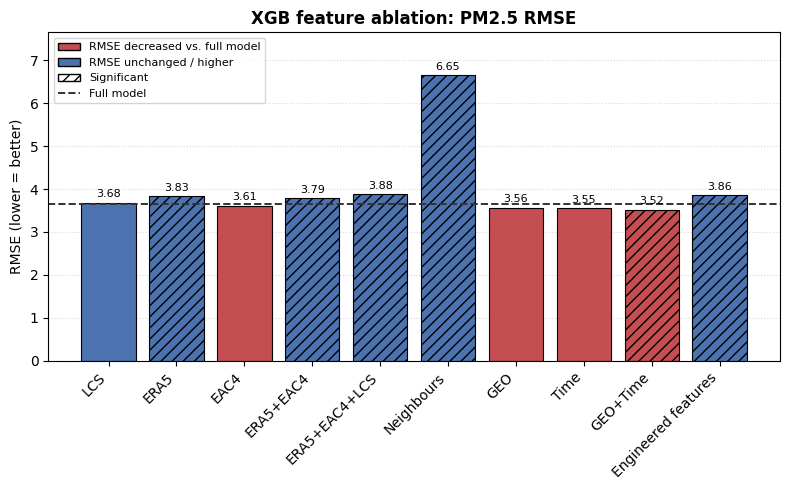

saved: figures\sq2_ablation_rmse_bars.png


In [ ]:
# RMSE figure
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, rmse_values, color=colors, edgecolor="black", linewidth=0.8)
for i in range(len(bars)):
    if sig_flags[i]:
        bars[i].set_hatch("///")
    ax.text(bars[i].get_x() + bars[i].get_width() / 2.0, rmse_values[i] + 0.08,
            "%.2f" % rmse_values[i], ha="center", va="bottom", fontsize=8)

ax.axhline(full_rmse, color="0.2", linestyle="--", linewidth=1.4)
ax.set_ylabel("RMSE (lower = better)")
ax.set_ylim(0, max(rmse_values) * 1.15)
ax.set_title("XGB feature ablation: PM2.5 RMSE", fontweight="bold")
ax.tick_params(axis="x", labelrotation=45)
for lbl in ax.get_xticklabels():
    lbl.set_ha("right")
ax.grid(axis="y", color="0.85", linestyle=":")
ax.set_axisbelow(True)
ax.legend(handles=legend_items, loc="upper left", fontsize=8, frameon=True)
fig.tight_layout()
fig.savefig(os.path.join(OUT_FIGURES, "sq2_ablation_rmse_bars.png"), dpi=200, bbox_inches="tight")
plt.show()
print("saved:", os.path.join(OUT_FIGURES, "sq2_ablation_rmse_bars.png"))

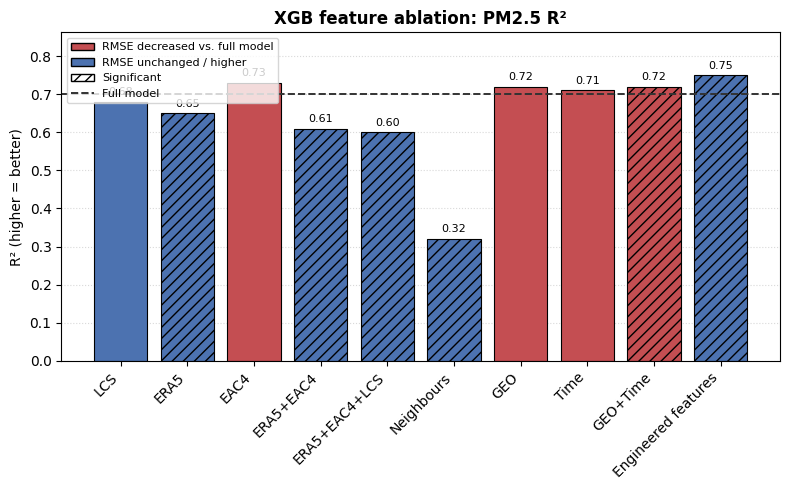

saved: figures\sq2_ablation_r2_bars.png


In [ ]:
# R2 figure, colors and hatching follow the RMSE comparison like in the thesis
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, r2_values, color=colors, edgecolor="black", linewidth=0.8)
for i in range(len(bars)):
    if sig_flags[i]:
        bars[i].set_hatch("///")
    ax.text(bars[i].get_x() + bars[i].get_width() / 2.0, r2_values[i] + 0.012,
            "%.2f" % r2_values[i], ha="center", va="bottom", fontsize=8)

ax.axhline(full_r2, color="0.2", linestyle="--", linewidth=1.4)
ax.set_ylabel("R² (higher = better)")
ax.set_ylim(0, max(r2_values) * 1.15)
ax.set_title("XGB feature ablation: PM2.5 R²", fontweight="bold")
ax.tick_params(axis="x", labelrotation=45)
for lbl in ax.get_xticklabels():
    lbl.set_ha("right")
ax.grid(axis="y", color="0.85", linestyle=":")
ax.set_axisbelow(True)
ax.legend(handles=legend_items, loc="upper left", fontsize=8, frameon=True)
fig.tight_layout()
fig.savefig(os.path.join(OUT_FIGURES, "sq2_ablation_r2_bars.png"), dpi=200, bbox_inches="tight")
plt.show()
print("saved:", os.path.join(OUT_FIGURES, "sq2_ablation_r2_bars.png"))